# Initialization

In [21]:
import pandas as pd
import csv
# Low Memory prevents pandas from inferring column types and avoids DtypeWarnings.
df = pd.read_csv('Employee_Compensation.csv', low_memory=False)

print(df.head())
print(f"Total number of reports: {len(df)}")
print(df.info())

   Organization Group Code Job Family Code Job Code Year Type  Year  \
0                        1            Q000     Q002    Fiscal  2016   
1                        2            1200     1241  Calendar  2016   
2                        6            1400     1402  Calendar  2016   
3                        4            2300     P103    Fiscal  2016   
4                        2            9200     9206    Fiscal  2016   

                        Organization Group Department Code  \
0                        Public Protection             POL   
1  Public Works, Transportation & Commerce             AIR   
2         General Administration & Finance             REG   
3                         Community Health             DPH   
4  Public Works, Transportation & Commerce             AIR   

               Department  Union Code  \
0              POL Police       911.0   
1  AIR Airport Commission        22.0   
2           REG Elections       790.0   
3       DPH Public Health       791.

# Pre-Processing


In [22]:
# Drops columns that arent needed, as well as any rows with NaN values.
df = df.drop(columns=["Organization Group Code", "Job Family Code", "Job Code", "Department Code", "Union Code", "Employee Name", "data_as_of", "data_loaded_at"])
df = df.dropna()

# Numerical columns are stored as objects in memory, so we need to change them into float values.
numerical_columns = [
    "Salaries",
    "Overtime",
    "Other Salaries",
    "Total Salary",
    "Total Benefits",
    "Total Compensation",
    "Hours",
]

for col in numerical_columns:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(",", "")
        )

print(df.head())
print(f"Total number of reports: {len(df)}")
print(df.info())

      Year Type  Year                       Organization Group  \
22940  Calendar  2017  Public Works, Transportation & Commerce   
22941  Calendar  2017                         Community Health   
22942    Fiscal  2017                     Culture & Recreation   
22943    Fiscal  2017                        Public Protection   
22944    Fiscal  2017                     Culture & Recreation   

                           Department                         Union  \
22940             Building Inspection        SEIU, Local 1021, Misc   
22941                   Public Health          SEIU, Local 1021, RN   
22942                    War Memorial        SEIU, Local 1021, Misc   
22943                         Sheriff  Deputy Sheriffs' Assoc (DSA)   
22944  Recreation And Park Commission        SEIU, Local 1021, Misc   

                    Job Family                             Job  Salaries  \
22940  Construction Inspection             Permit Technician I    968.50   
22941                  N

# Analysis

In [23]:
# Here we take the average of all jobs Total Compensation to see the top 10 highest paying jobs.
job_average_skewed = df.groupby('Job')['Total Compensation'].agg(['mean', 'count']).sort_values(by='mean', ascending=False)
print(job_average_skewed.head(10))

                                         mean  count
Job                                                 
Chf Executive & Investment Ofc  738305.711111      9
Chief Investment Officer        714305.057778      9
Chief Executive Officer         689307.350000      2
Managing Director               600722.491806     72
Physician Administrator, DPH    585101.330625     32
Director                        522924.331084     83
Sup Psychiatric Physician Spec  520955.406774     62
COO - Retirement System         517983.912500      8
Sheriff                         490901.246667     12
Chief, Fire Department          475686.445455     22


In [24]:
job_average = df.groupby('Job')['Total Compensation'].agg(['mean', 'count'])

# We require a minimum count here so the top jobs aren't skewed toward extremely rare ones (like Executive Officers in the previous cell).
job_average = job_average[job_average['count'] > 25]

job_average = job_average.sort_values(by='mean', ascending=False)
print(job_average.head(10))

                                         mean  count
Job                                                 
Managing Director               600722.491806     72
Physician Administrator, DPH    585101.330625     32
Director                        522924.331084     83
Sup Psychiatric Physician Spec  520955.406774     62
Administrator, DPH              473391.679615     52
Executive Contract Employee     427070.899333     30
Assistant Chief of Police       410751.431364     44
Dept Head V                     409861.998214     84
Deputy Chief 3                  402327.178750    104
Asst Chf of Dept (Fire Dept)    400318.876216    111


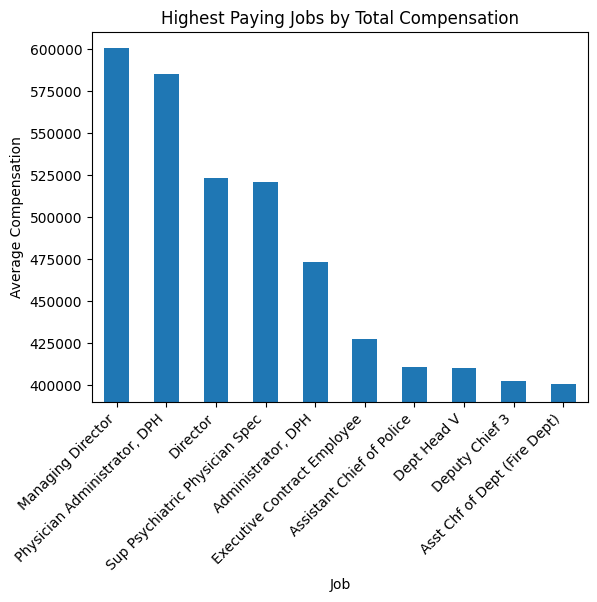

In [25]:
import matplotlib.pyplot as plt

best_jobs = job_average.head(10) # Grabs the 10 jobs we determined in the last cell to be graphed.
best_jobs['mean'].plot(kind='bar')
plt.title('Highest Paying Jobs by Total Compensation')
plt.xlabel('Job')
plt.ylabel('Average Compensation')
plt.xticks(rotation=45, ha='right') # Rotates x axis labels for readability
plt.ylim(390000, 610000) # Changes range of y
plt.show()

In [38]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = df.groupby('Job')[['Total Compensation', 'Overtime']].mean()
features = features.dropna()

# The original Overtime column lists the amount of money paid for overtime, and not the hours of overtime worked.
# It's more beneficial to our analysis to see the percentage of total compensation that came from overtime hours.
features['Overtime Ratio'] = (features['Overtime'] / features['Total Compensation'])

features = features[['Total Compensation', 'Overtime Ratio']]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_features)

features['Cluster'] = clusters

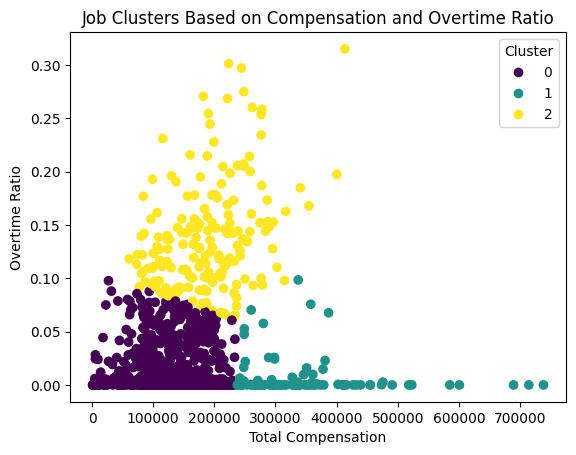

         Total Compensation  Overtime Ratio
Cluster                                    
0             129311.505929        0.013344
1             334388.696654        0.006243
2             188683.453253        0.138760 

 Cluster
0    903
2    182
1    112
Name: count, dtype: int64


In [50]:
scatter = plt.scatter(features['Total Compensation'], features['Overtime Ratio'], c=features['Cluster'])

plt.xlabel('Total Compensation')
plt.ylabel('Overtime Ratio')
plt.title('Job Clusters Based on Compensation and Overtime Ratio')
plt.legend(*scatter.legend_elements(), title='Cluster')
plt.show()
print(features.groupby('Cluster').mean(), "\n\n", features['Cluster'].value_counts())

In [54]:
print("Best Jobs Per Cluster\n")
for cluster in sorted(features['Cluster'].unique()):
  print(f"Cluster {cluster}:")

  clustered_jobs = features[features['Cluster'] == cluster]

  best_jobs = clustered_jobs.sort_values(by='Total Compensation', ascending=False).head(10)
  print(best_jobs[['Total Compensation', 'Overtime Ratio']])

Best Jobs Per Cluster

Cluster 0:
                                Total Compensation  Overtime Ratio
Job                                                               
Imaging Supervisor                   233667.772672        0.042905
Supt Water Treatment Fac             232980.901613        0.025919
Div Director, Adult Probation        230693.401690        0.000000
Chief Electrical Inspector           230220.816316        0.002849
Mayoral Staff XVI                    229818.296689        0.000000
Administrative Engineer              229501.862638        0.000000
Assistant Court Reporter Coord       229284.174286        0.004224
Lab Svcs Mgr                         228822.582222        0.000000
Electrician Supervisor II            228708.185660        0.060637
Director,Juvenile Hall (SFERS)       228524.720000        0.000000
Cluster 1:
                                Total Compensation  Overtime Ratio
Job                                                               
Chf Executive & I

In [55]:
print("Worst Jobs Per Cluster\n")
for cluster in sorted(features['Cluster'].unique()):
  print(f"Cluster {cluster}:")

  clustered_jobs = features[features['Cluster'] == cluster]

  worst_jobs = clustered_jobs.sort_values(by='Total Compensation', ascending=True).head(10)
  print(worst_jobs[['Total Compensation', 'Overtime Ratio']])

Worst Jobs Per Cluster

Cluster 0:
                                Total Compensation  Overtime Ratio
Job                                                               
BdComm Mbr, Grp2,M=$25/Mtg              931.250913        0.000000
Recreation Director                    1524.443333        0.000000
Bail Commissioner                      1685.990000        0.000000
BdComm Mbr, Grp3 M=$50/Mtg             1936.687388        0.000000
Commissioner No Benefits               2139.458411        0.000000
BdComm Mbr, Grp5,M$100/Mo              2221.289381        0.000000
Camp Assistant                         4610.255911        0.005986
Pre-Appren Automotive Mechanic         5034.592411        0.001457
Special Assistant 22                   5043.430000        0.000000
Assistant Recreation Director          5156.910000        0.000000
Cluster 1:
                                Total Compensation  Overtime Ratio
Job                                                               
Chf Distt Atty I

In [57]:
print("Jobs With The Most Overtime\n")
clustered_jobs = features[features['Cluster'] == cluster]

overtime_jobs = clustered_jobs.sort_values(by='Overtime Ratio', ascending=False).head(10)
print(overtime_jobs[['Total Compensation', 'Overtime Ratio']])

Jobs With The Most Overtime

                               Total Compensation  Overtime Ratio
Job                                                              
Sheriff's Lieutenant (SFERS)        413546.650000        0.314908
Sr Cnselor, JH & LGR (SFERS)        223398.010000        0.301144
Transit Power Line Sprv1            244442.460171        0.296971
Institutional Police Sergeant       248433.662500        0.274948
Counselor 2 (SFERS)                 182094.677273        0.270376
Transit Power Line Worker           221735.481401        0.268385
Line Inspector                      262044.734737        0.260139
Senior Deputy Sheriff               277957.951805        0.258319
Pilot of Fire Boats                 190290.072451        0.254263
Mech Shop & Equip Supt              276737.333529        0.253558
